<a href="https://colab.research.google.com/github/Bia-byte/gerador_fsk/blob/main/gerador_FSK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sequência de bits: [0 1 1 0 1 1 1 1 1 1 1 0 0]


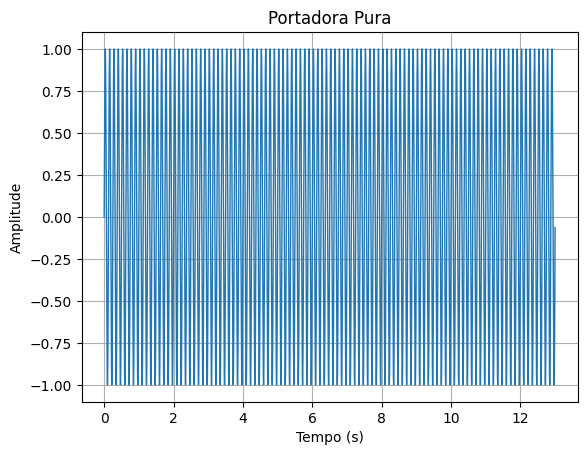

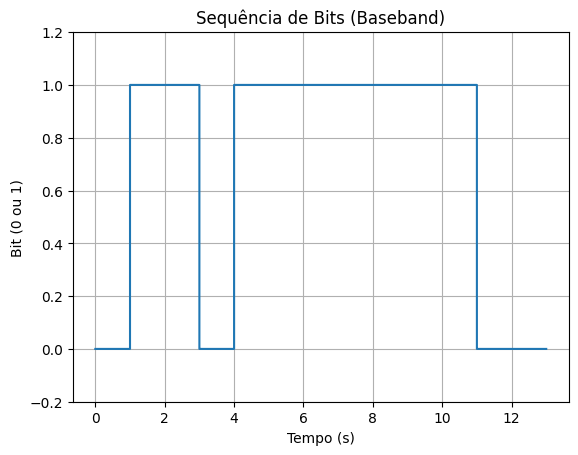

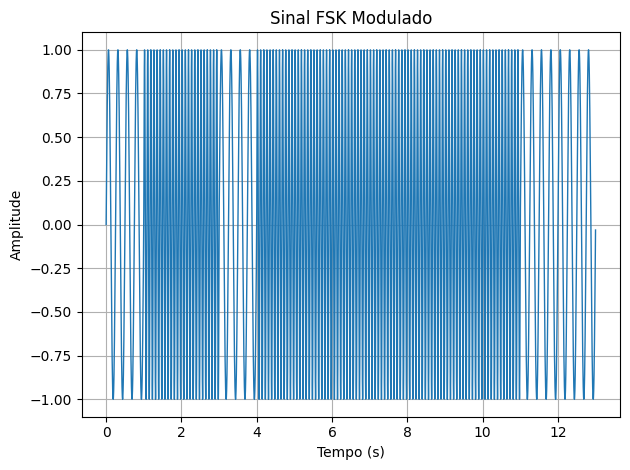

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros
num_bits = 13          # número total de bits a serem gerados e transmitidos.
R = 1                  # taxa de bits como 1 bit/segundo. Isso significa que cada bit tem uma duração de 1 segundo.
fp = 8.0               # frequência da portadora em (Hz). Esta é a frequência base que será modulada.
f_dev = 4.0            # desvio de frequência em (Hz). Este valor determina o quanto a frequência da portadora irá variar para representar os bits 0 e 1.
# O desvio é simétrico em torno da frequência da portadora (+/- 4 Hz). Isso resulta em frequências de f0 = fp - f_dev = 4 Hz para o bit 0 e f1 = fp + f_dev = 12 Hz para o bit 1.
amostras_por_bit = 800 # número de amostras usadas para representar cada bit no sinal digital. Um número maior de amostras por bit resulta em uma forma de onda mais suave e contínua quando visualizada.

# Gera sequência de bits
np.random.seed(0)       # Define uma semente para o gerador de números aleatórios. Isso garante que a mesma sequência de bits seja gerada cada vez que o código é executado.
bit_seq = np.random.randint(0, 2, num_bits) # Gera uma array com os 'num_bits' inteiros aleatórios entre 0 a 2 (exclusive), representando a sequência de bits a ser transmitida.
print("Sequência de bits:", bit_seq) # Imprime a sequência de bits gerada no console.

# Preparação do tempo e frequências
Tb = 1.0 / R           # Calcula a duração de cada bit em [seg]. Como a taxa de bits (R) é 1 bit/segundo, a duração de cada bit é 1 segundo.
t_bit = np.linspace(0, Tb, amostras_por_bit, endpoint=False) # Gera um array 'amostras_por_bit' pontos de tempo uniformemente espaçados dentro da duração de um único bit (de 0 a Tb, exclusive o ponto final).
# Este array representa a linha de tempo para um único bit.
total_amostras = amostras_por_bit * num_bits # Calcula o número total de amostras necessárias para representar toda a sequência de bits.
f1 = fp + f_dev        # Calcula a frequência que será usada para representar o bit '1' no sinal FSK (Frequency-Shift Keying).
f0 = fp - f_dev        # Calcula a frequência que será usada para representar o bit '0' no sinal FSK.

# Prealoca arrays
t = np.zeros(total_amostras) # Cria um array preenchido com zeros para armazenar os valores de tempo correspondentes a todas as amostras do sinal FSK.
sinal_fsk = np.zeros(total_amostras) # Cria um array preenchido com zeros para armazenar os valores de amplitude do sinal FSK modulado.

# Geração do sinal FSK
for i, bit in enumerate(bit_seq): # Loop que itera sobre cada bit na sequência de bits, com 'i' sendo o índice e 'bit' sendo o valor do bit (0 ou 1).
    começa = i * amostras_por_bit # Calcula o índice inicial no array de tempo e sinal FSK para o bit atual.
    termina = começa + amostras_por_bit # Calcula o índice final no array de tempo e sinal FSK para o bit atual.
    t[começa:termina] = t_bit + i * Tb # Preenche a seção correspondente do array de tempo ('t') para o bit atual. Adiciona 'i * Tb' para garantir que o tempo seja contínuo ao longo de todos os bits.
    freq = f1 if bit == 1 else f0 # Determina a frequência a ser usada para o bit atual. Se o bit for 1, usa a frequência 'f1'; se for 0, usa a frequência 'f0'.
    sinal_fsk[começa:termina] = np.sin(2 * np.pi * freq * t_bit) # Gera a forma de onda senoidal para o bit atual usando a frequência determinada e os pontos de tempo de 't_bit', e armazena essa forma de onda

# Geração do sinal da portadora pura
portadora = np.sin(2 * np.pi * fp * t) # Gera uma onda senoidal pura na frequência da portadora ('fp') ao longo do tempo total ('t'). Isso representa o sinal da portadora antes da modulação.

# Geração da sequência de bits como waveform
sequência_de_dados = np.repeat(bit_seq, amostras_por_bit) # Repete cada bit na 'bit_seq' 'amostras_por_bit' vezes para criar uma representação em forma de degrau da sequência de bits ao longo do tempo.

# Plot 1: portadora pura
plt.figure(1)
plt.plot(t, portadora, linewidth=1)
plt.title("Portadora Pura")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)

# Plot 2: sequência de bits
plt.figure(2)
plt.step(t, sequência_de_dados, where='post')
plt.ylim(-0.2, 1.2)
plt.title("Sequência de Bits (Baseband)")
plt.xlabel("Tempo (s)")
plt.ylabel("Bit (0 ou 1)")
plt.grid(True)

# Plot 3: sinal FSK
plt.figure(3)
plt.plot(t, sinal_fsk, linewidth=1)
plt.title("Sinal FSK Modulado")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()